# Exploratory Data Analysis

Analisis ini menggunakan `data/processed/master_daily.parquet` dan seluruh perhitungan return hanya memakai informasi harga yang tersedia pada dataset master. Beta dihitung ulang terhadap return LQ45, bukan memakai kolom beta dari `summary_metrics`.

In [3]:
from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import jarque_bera
from statsmodels.tsa.stattools import adfuller
from IPython.display import display, Markdown

sns.set_theme(style='whitegrid', context='notebook')
project_candidates = [Path.cwd(), Path.cwd().parent]
PROJECT_ROOT = next((p.resolve() for p in project_candidates if (p / 'data' / 'processed').exists()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Root project tidak ditemukan.')
MASTER_PATH = PROJECT_ROOT / 'data' / 'processed' / 'master_daily.parquet'
master = pd.read_parquet(MASTER_PATH)
master['date'] = pd.to_datetime(master['date'], errors='raise')
master = master.sort_values('date').set_index('date')

stock_cols = ['BBCA.JK', 'BBRI.JK', 'BMRI.JK', 'BBNI.JK', 'TLKM.JK', 'EXCL.JK', 'ASII.JK', 'UNTR.JK', 'UNVR.JK', 'ICBP.JK', 'INDF.JK', 'KLBF.JK', 'ANTM.JK', 'PTBA.JK', 'ITMG.JK']
assert set(stock_cols).issubset(master.columns) and len(stock_cols) == 15
assert master.index.is_monotonic_increasing and not master.index.duplicated().any()

prices = master[stock_cols]
stock_returns = np.log(prices / prices.shift(1))
lq45_return = np.log(master['lq45'] / master['lq45'].shift(1)).rename('lq45_return')
display(Markdown(f'**Observations:** {len(master):,} hari | **Periode:** {master.index.min().date()} sampai {master.index.max().date()} | **Saham:** {len(stock_cols)}'))

**Observations:** 2,410 hari | **Periode:** 2016-09-22 sampai 2026-09-21 | **Saham:** 15

## 1. Distribusi log-return, skewness, kurtosis, dan Jarque-Bera

,Observations,Mean,Std,Skewness,Kurtosis_Fisher,JB_stat,JB_pvalue,Reject_normality_5pct
Ticker,,,,,,,,
PTBA.JK,2409,0.000687,0.024800,0.056906,8.339162,6948.452115,0.000000e+00,True
UNVR.JK,2409,-0.000552,0.022064,0.710611,8.040641,6661.022960,0.000000e+00,True
BBCA.JK,2409,0.000390,0.015777,0.413756,7.442051,5601.079954,0.000000e+00,True
INDF.JK,2409,0.000070,0.017422,0.234152,7.292363,5334.024983,0.000000e+00,True
EXCL.JK,2409,0.000044,0.027752,0.468802,5.774165,3417.981977,0.000000e+00,True
TLKM.JK,2409,-0.000007,0.019483,0.059726,5.728758,3279.095320,0.000000e+00,True
BBRI.JK,2409,0.000377,0.020026,0.309129,5.379004,2927.819664,0.000000e+00,True
ANTM.JK,2409,0.000770,0.030278,0.946262,5.182876,3041.594960,0.000000e+00,True
UNTR.JK,2409,0.000430,0.023627,0.190525,5.026619,2537.703680,0.000000e+00,True


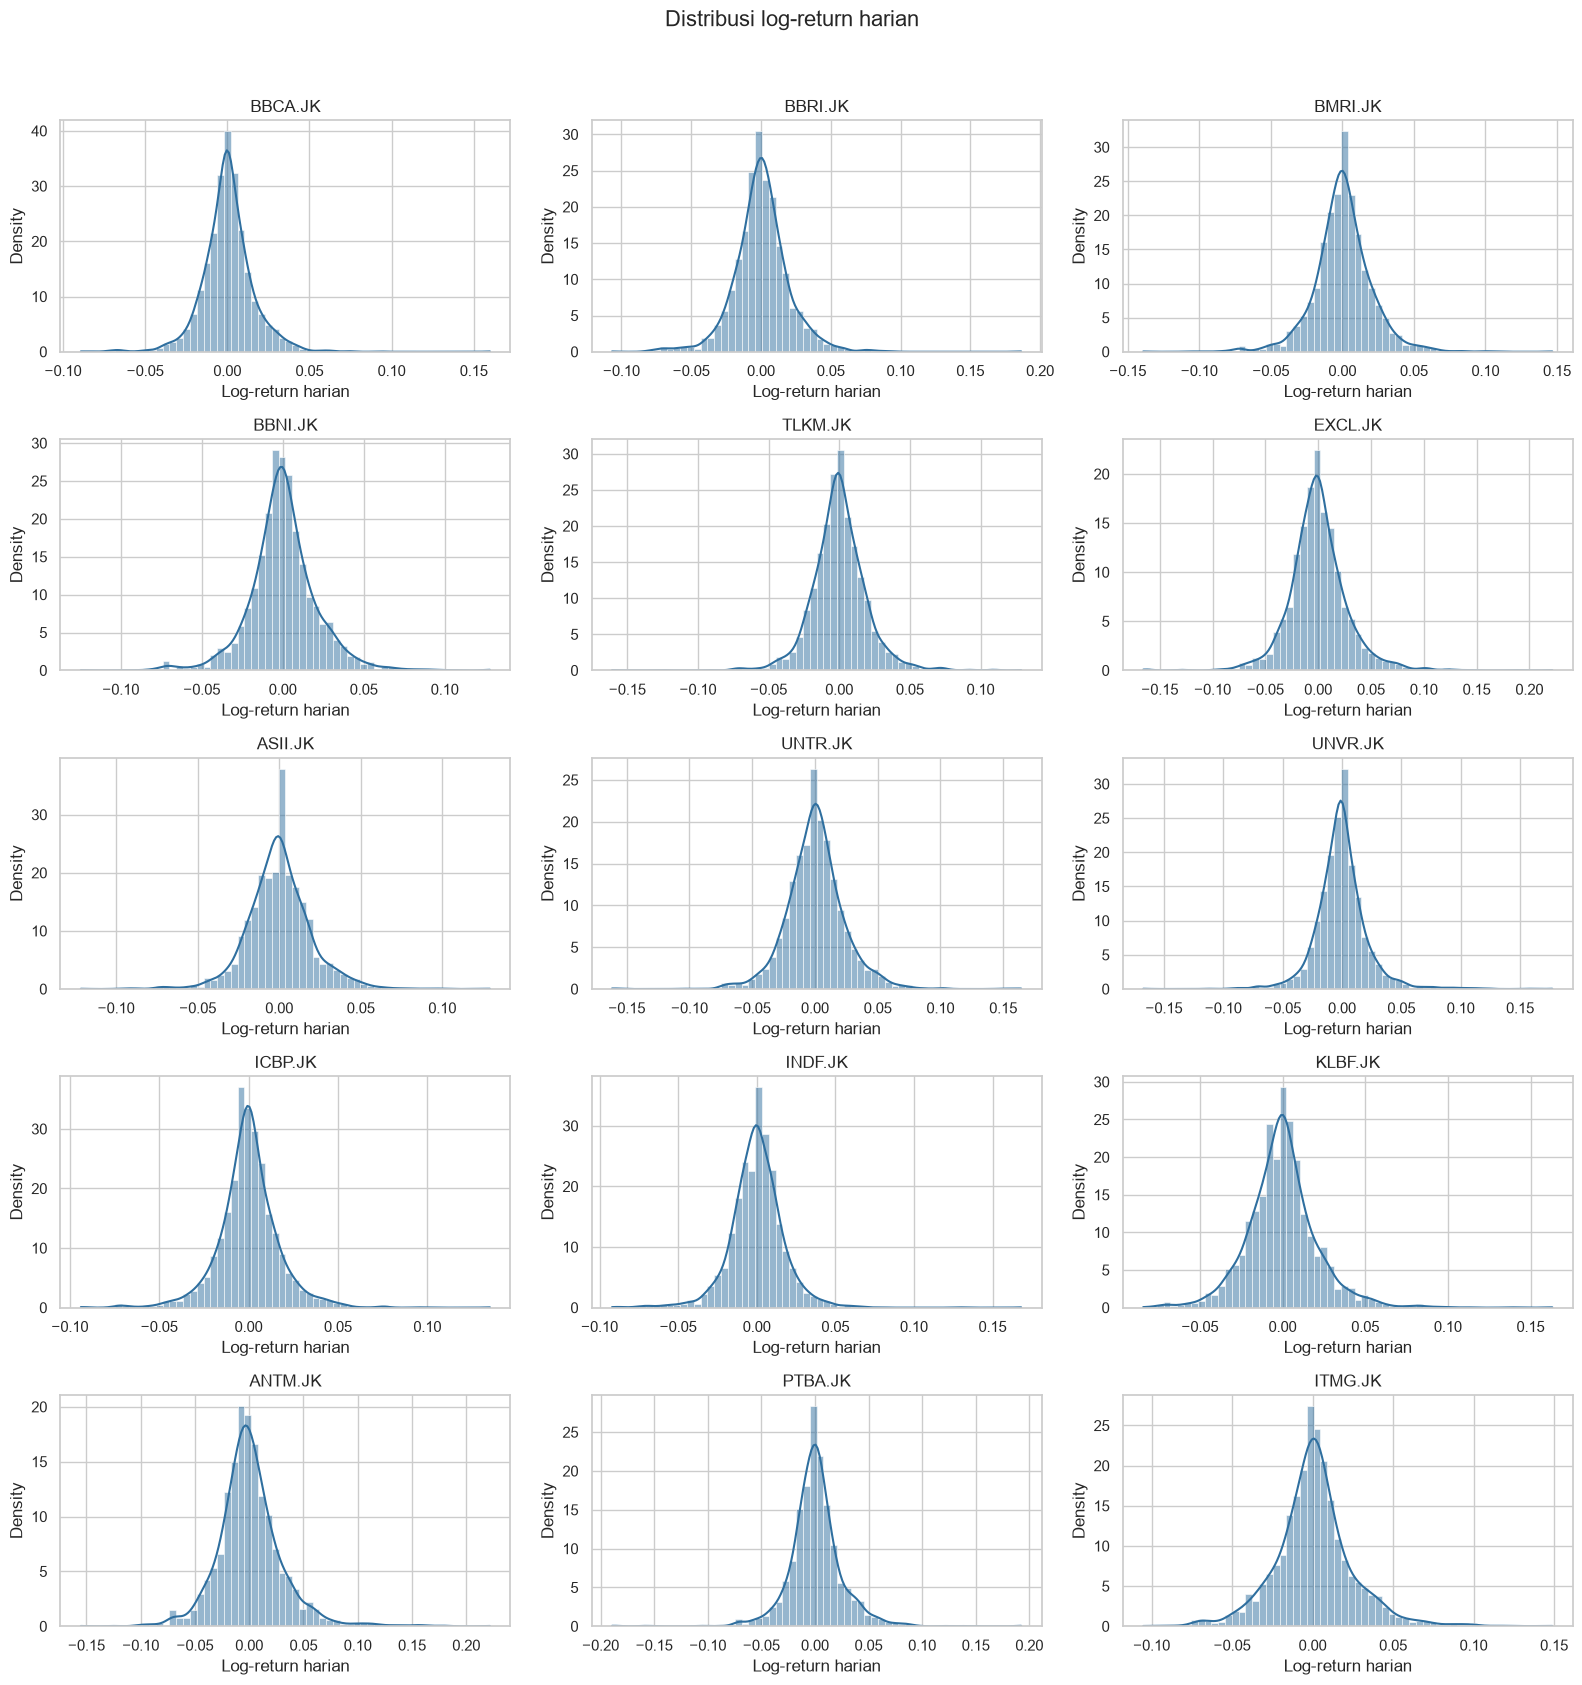

In [4]:
distribution_rows = []
for ticker in stock_cols:
    series = stock_returns[ticker].dropna()
    jb = jarque_bera(series)
    distribution_rows.append({
        'Ticker': ticker,
        'Observations': len(series),
        'Mean': series.mean(),
        'Std': series.std(),
        'Skewness': series.skew(),
        'Kurtosis_Fisher': series.kurt(),
        'JB_stat': jb.statistic,
        'JB_pvalue': jb.pvalue,
        'Reject_normality_5pct': jb.pvalue < 0.05,
    })
distribution_stats = pd.DataFrame(distribution_rows).set_index('Ticker').sort_values('Kurtosis_Fisher', ascending=False)
display(distribution_stats)

ncols = 3
nrows = math.ceil(len(stock_cols) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.3 * nrows), sharex=False)
for ax, ticker in zip(np.asarray(axes).ravel(), stock_cols):
    sns.histplot(stock_returns[ticker].dropna(), bins=60, kde=True, stat='density', ax=ax, color='#2f6f9f')
    ax.set_title(ticker)
    ax.set_xlabel('Log-return harian')
for ax in np.asarray(axes).ravel()[len(stock_cols):]:
    ax.remove()
fig.suptitle('Distribusi log-return harian', y=1.02, fontsize=16)
fig.tight_layout()
plt.show()

## 2. Uji stasioneritas ADF pada harga dan return

Hipotesis nol ADF adalah adanya unit root. P-value di bawah 0,05 ditandai sebagai stasioner pada tingkat signifikansi 5%.

In [5]:
def adf_result(series, ticker, series_type):
    clean = series.dropna()
    result = adfuller(clean, autolag='AIC', regression='c')
    return {
        'Ticker': ticker,
        'Series': series_type,
        'ADF_stat': result[0],
        'pvalue': result[1],
        'used_lag': result[2],
        'Observations': result[3],
        'Stationary_5pct': result[1] < 0.05,
    }

adf_rows = []
for ticker in stock_cols:
    adf_rows.append(adf_result(prices[ticker], ticker, 'price'))
    adf_rows.append(adf_result(stock_returns[ticker], ticker, 'log_return'))
adf_results = pd.DataFrame(adf_rows).set_index(['Ticker', 'Series'])
display(adf_results)
display(adf_results.groupby(level='Series')['Stationary_5pct'].agg(['sum', 'count']).rename(columns={'sum': 'stationary_count'}))

C:\Users\abiyy\AppData\Local\Temp\ipykernel_18880\3739306781.py:3: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(clean, autolag='AIC', regression='c')
C:\Users\abiyy\AppData\Local\Temp\ipykernel_18880\3739306781.py:3: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(clean, autolag='AIC', regression='c')
C:\Users\abiyy\AppData\Local\Temp\ip

ADF_stat        pvalue  used_lag  Observations  \
Ticker  Series                                                        
BBCA.JK price       -1.770831  3.950364e-01         2          2407   
        log_return -37.338015  0.000000e+00         1          2407   
BBRI.JK price       -1.892112  3.357809e-01         9          2400   
        log_return -19.541998  0.000000e+00         6          2402   
BMRI.JK price       -1.126082  7.045593e-01        10          2399   
        log_return -17.807416  3.199512e-30         9          2399   
BBNI.JK price       -1.964527  3.023401e-01         7          2402   
        log_return -46.623186  0.000000e+00         0          2408   
TLKM.JK price       -2.452543  1.274520e-01        10          2399   
        log_return  -9.511390  3.242283e-16        27          2381   
EXCL.JK price       -3.445785  9.493636e-03        17          2392   
        log_return -21.770259  0.000000e+00         4          2404   
ASII.JK price       -2.533297  1.075816e-01         2          2407   
        log_return -38.323883  0.000000e+00         1          2407   
UNTR.JK price       -1.819410  3.708684e-01         2          2407   
        log_return -38.469850  0.000000e+00         1          2407   
UNVR.JK price       -0.570279  8.775573e-01        13          2396   
        log_return -22.916210  0.000000e+00         3          2405   
ICBP.JK price       -1.752683  4.041934e-01        16          2393   
        log_return -19.071907  0.000000e+00         8          2400   
INDF.JK price       -2.204978  2.044436e-01         4          2405   
        log_return -27.936991  0.000000e+00         3          2405   
KLBF.JK price       -1.515038  5.260597e-01         2          2407   
        log_return -38.725998  0.000000e+00         1          2407   
ANTM.JK price       -0.802204  8.184739e-01        15          2394   
        log_return -26.938973  0.000000e+00         2          2406   
PTBA.JK price       -0.495040  8.929809e-01         2          2407   
        log_return -20.417090  0.000000e+00         5          2403   
ITMG.JK price       -0.676022  8.528630e-01         7          2402   
        log_return -21.908847  0.000000e+00         3          2405   

                    Stationary_5pct  
Ticker  Series                       
BBCA.JK price                 False  
        log_return             True  
BBRI.JK price                 False  
        log_return             True  
BMRI.JK price                 False  
        log_return             True  
BBNI.JK price                 False  
        log_return             True  
TLKM.JK price                 False  
        log_return             True  
EXCL.JK price                  True  
        log_return             True  
ASII.JK price                 False  
        log_return             True  
UNTR.JK price                 False  
        log_return             True  
UNVR.JK price                 False  
        log_return             True  
ICBP.JK price                 False  
        log_return             True  
INDF.JK price                 False  
        log_return             True  
KLBF.JK price                 False  
        log_return             True  
ANTM.JK price                 False  
        log_return             True  
PTBA.JK price                 False  
        log_return             True  
ITMG.JK price                 False  
        log_return             True

,stationary_count,count
Series,,
log_return,15,15
price,1,15


## 3. Korelasi return dan rolling correlation terhadap LQ45

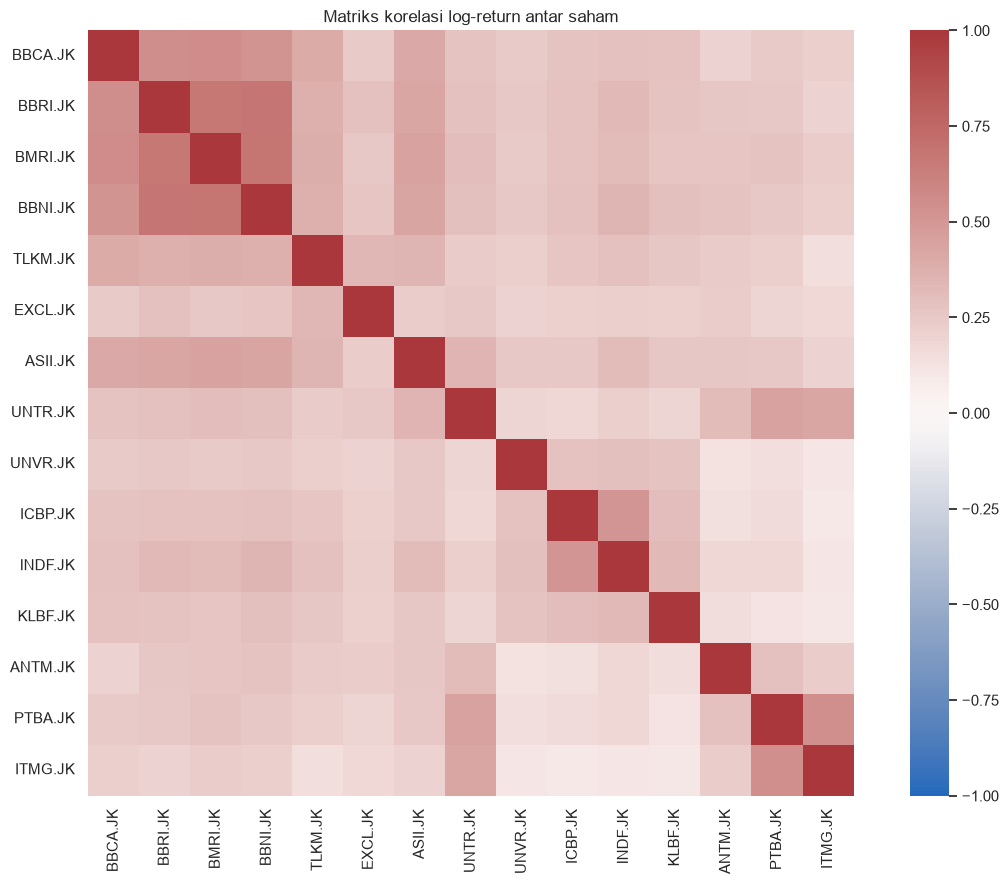

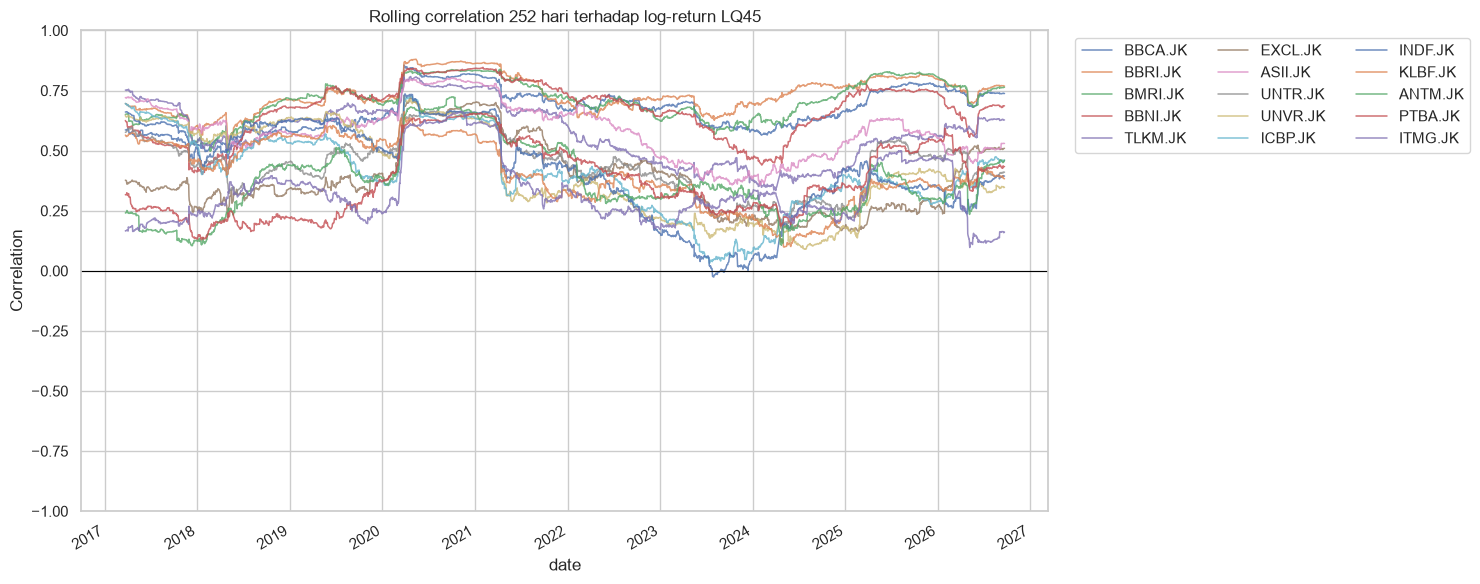

,Ticker_1,Ticker_2,Correlation
27,BMRI.JK,BBNI.JK,0.680193
15,BBRI.JK,BBNI.JK,0.673058
14,BBRI.JK,BMRI.JK,0.667343
1,BBCA.JK,BMRI.JK,0.562232
0,BBCA.JK,BBRI.JK,0.553328
104,PTBA.JK,ITMG.JK,0.539590
2,BBCA.JK,BBNI.JK,0.521415
90,ICBP.JK,INDF.JK,0.509312
82,UNTR.JK,PTBA.JK,0.448549
30,BMRI.JK,ASII.JK,0.446557


,Mean_rolling_corr
BBRI.JK,0.733173
BMRI.JK,0.710807
BBNI.JK,0.671760
BBCA.JK,0.667668
ASII.JK,0.584632
TLKM.JK,0.576087
UNTR.JK,0.441405
INDF.JK,0.420551
UNVR.JK,0.415622
KLBF.JK,0.407496


In [6]:
return_corr = stock_returns.corr()
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(return_corr, cmap='vlag', center=0, vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title('Matriks korelasi log-return antar saham')
plt.tight_layout()
plt.show()

rolling_corr_252 = stock_returns.apply(lambda s: s.rolling(252, min_periods=126).corr(lq45_return))
fig, ax = plt.subplots(figsize=(15, 6))
rolling_corr_252.plot(ax=ax, linewidth=1.1, alpha=0.8)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylim(-1, 1)
ax.set_title('Rolling correlation 252 hari terhadap log-return LQ45')
ax.set_ylabel('Correlation')
ax.legend(ncol=3, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

pair_values = []
for i, left in enumerate(stock_cols):
    for right in stock_cols[i + 1:]:
        pair_values.append({'Ticker_1': left, 'Ticker_2': right, 'Correlation': return_corr.loc[left, right]})
display(pd.DataFrame(pair_values).sort_values('Correlation', ascending=False).head(10))
display(rolling_corr_252.mean().sort_values(ascending=False).rename('Mean_rolling_corr').to_frame())

## 4. Volatilitas rolling 30 hari dan periode krisis

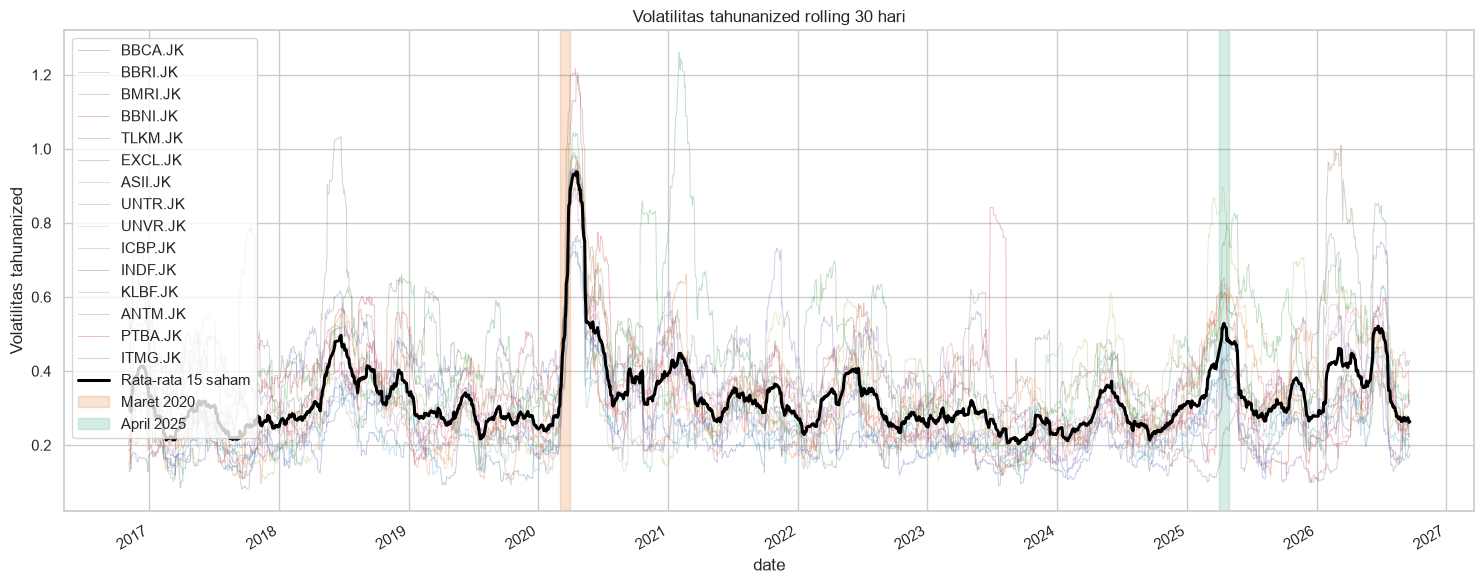

,Mean_cross_sectional_vol,Peak_cross_sectional_vol,Peak_date,Mean_vol_all_stock_days
Periode,,,,
Maret 2020,0.550580,0.891745,2020-03-31,0.550580
April 2025,0.502901,0.528174,2025-04-16,0.502901


Volatilitas rata-rata seluruh periode: **32.1%**

In [7]:
rolling_vol_30 = stock_returns.rolling(30, min_periods=30).std() * np.sqrt(252)
cross_sectional_vol = rolling_vol_30.mean(axis=1)
crisis_periods = {
    'Maret 2020': (pd.Timestamp('2020-03-01'), pd.Timestamp('2020-03-31')),
    'April 2025': (pd.Timestamp('2025-04-01'), pd.Timestamp('2025-04-30')),
}

fig, ax = plt.subplots(figsize=(15, 6))
rolling_vol_30.plot(ax=ax, linewidth=0.7, alpha=0.35, legend=False)
cross_sectional_vol.plot(ax=ax, color='black', linewidth=2.2, label='Rata-rata 15 saham')
colors = ['#d95f02', '#1b9e77']
for (label, (start, end)), color in zip(crisis_periods.items(), colors):
    ax.axvspan(start, end, color=color, alpha=0.18, label=label)
ax.set_title('Volatilitas tahunanized rolling 30 hari')
ax.set_ylabel('Volatilitas tahunanized')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

crisis_rows = []
for label, (start, end) in crisis_periods.items():
    window = rolling_vol_30.loc[start:end]
    crisis_rows.append({
        'Periode': label,
        'Mean_cross_sectional_vol': cross_sectional_vol.loc[start:end].mean(),
        'Peak_cross_sectional_vol': cross_sectional_vol.loc[start:end].max(),
        'Peak_date': cross_sectional_vol.loc[start:end].idxmax(),
        'Mean_vol_all_stock_days': window.mean().mean(),
    })
crisis_summary = pd.DataFrame(crisis_rows).set_index('Periode')
display(crisis_summary)
display(Markdown(f'Volatilitas rata-rata seluruh periode: **{cross_sectional_vol.mean():.1%}**'))

## 5. BI Rate, USDIDR, PMI-BI, dan return LQ45

Panel pertama menampilkan z-score agar level dengan satuan berbeda dapat dibandingkan. Panel kedua memakai perubahan harian dari variabel makro yang bertangga dan log-return USDIDR.

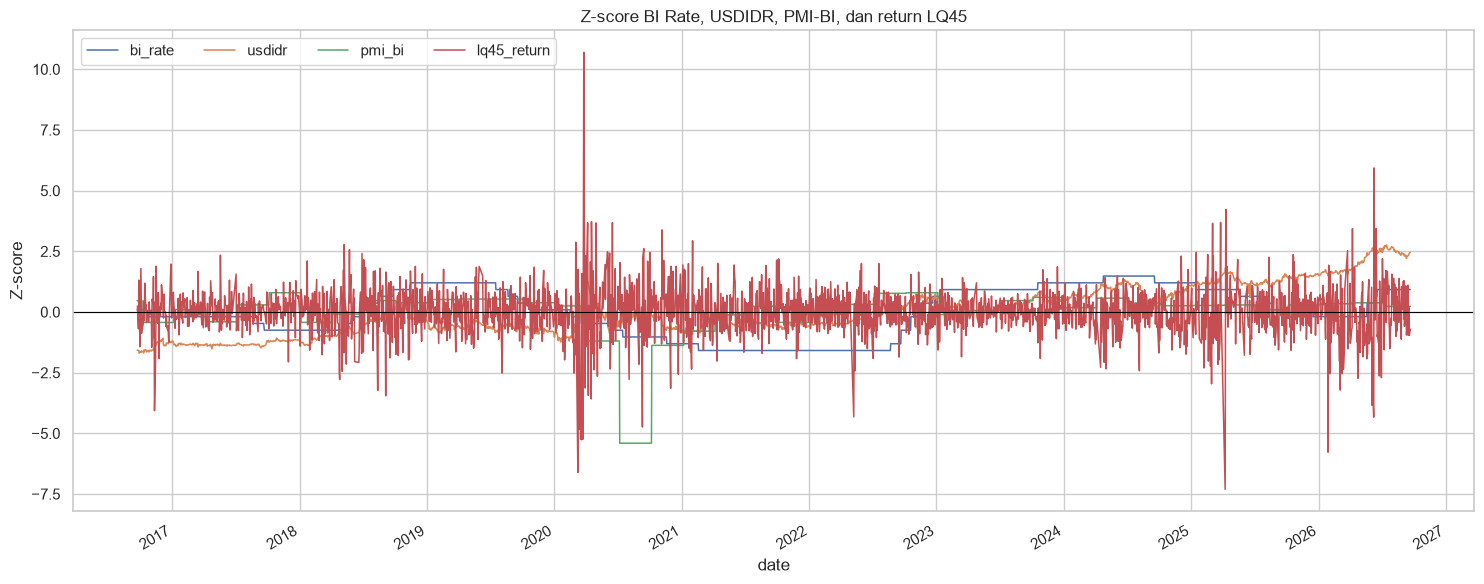

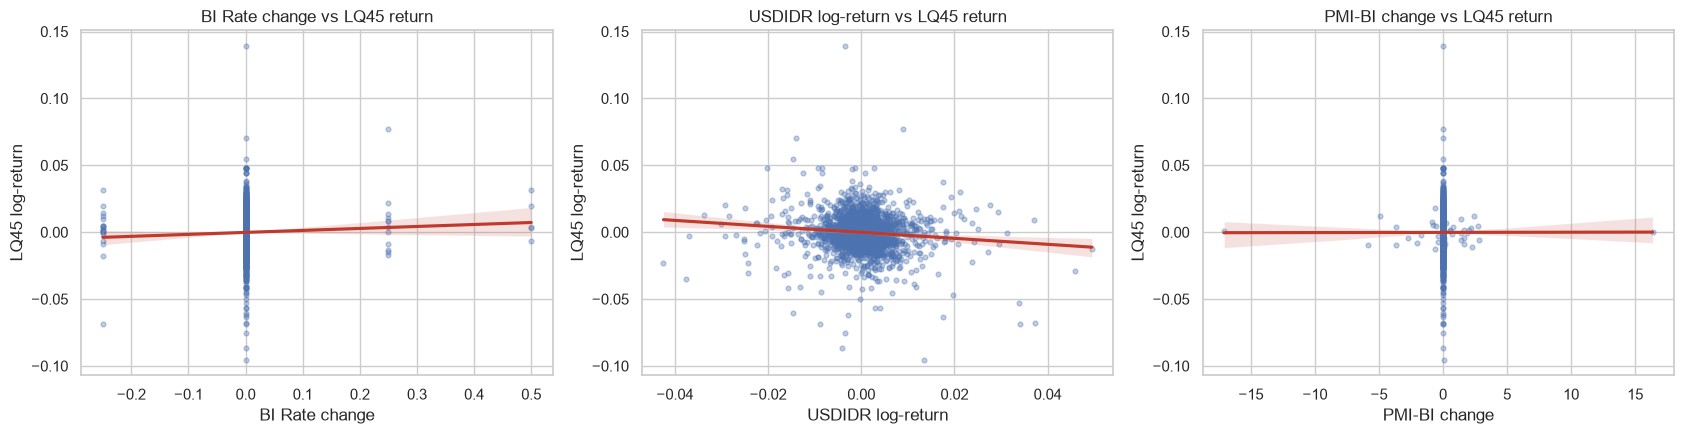

,Correlation_with_LQ45_return
USDIDR log-return,-0.108199
PMI-BI change,0.000570
BI Rate change,0.041323


In [8]:
relationship_levels = master[['bi_rate', 'usdidr', 'pmi_bi']].copy()
relationship_levels['lq45_return'] = lq45_return
relationship_z = (relationship_levels - relationship_levels.mean()) / relationship_levels.std()
fig, ax = plt.subplots(figsize=(15, 6))
relationship_z.plot(ax=ax, linewidth=1.1)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Z-score BI Rate, USDIDR, PMI-BI, dan return LQ45')
ax.set_ylabel('Z-score')
ax.legend(ncol=4, loc='upper left')
plt.tight_layout()
plt.show()

macro_changes = pd.DataFrame({
    'BI Rate change': master['bi_rate'].diff(),
    'USDIDR log-return': np.log(master['usdidr'] / master['usdidr'].shift(1)),
    'PMI-BI change': master['pmi_bi'].diff(),
    'LQ45 log-return': lq45_return,
}).dropna()
macro_corr = macro_changes.corr()['LQ45 log-return'].drop('LQ45 log-return').sort_values()
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for ax, col in zip(axes, ['BI Rate change', 'USDIDR log-return', 'PMI-BI change']):
    sns.regplot(data=macro_changes, x=col, y='LQ45 log-return', scatter_kws={'s': 12, 'alpha': 0.35}, line_kws={'color': '#c0392b'}, ax=ax)
    ax.set_title(f'{col} vs LQ45 return')
plt.tight_layout()
plt.show()
display(macro_corr.rename('Correlation_with_LQ45_return').to_frame())

## 6. Beta tiap saham terhadap LQ45

Beta dihitung sebagai `cov(return_saham, return_LQ45) / var(return_LQ45)` menggunakan periode observasi yang sama. Nilai ini menggantikan beta pada `summary_metrics`.

,Beta_vs_LQ45,Observations
Ticker,,
BBRI.JK,1.179210,2409
BMRI.JK,1.176152,2409
BBNI.JK,1.161064,2409
ANTM.JK,1.018414,2409
ASII.JK,0.947114,2409
EXCL.JK,0.933823,2409
TLKM.JK,0.919993,2409
BBCA.JK,0.858389,2409
UNTR.JK,0.857562,2409


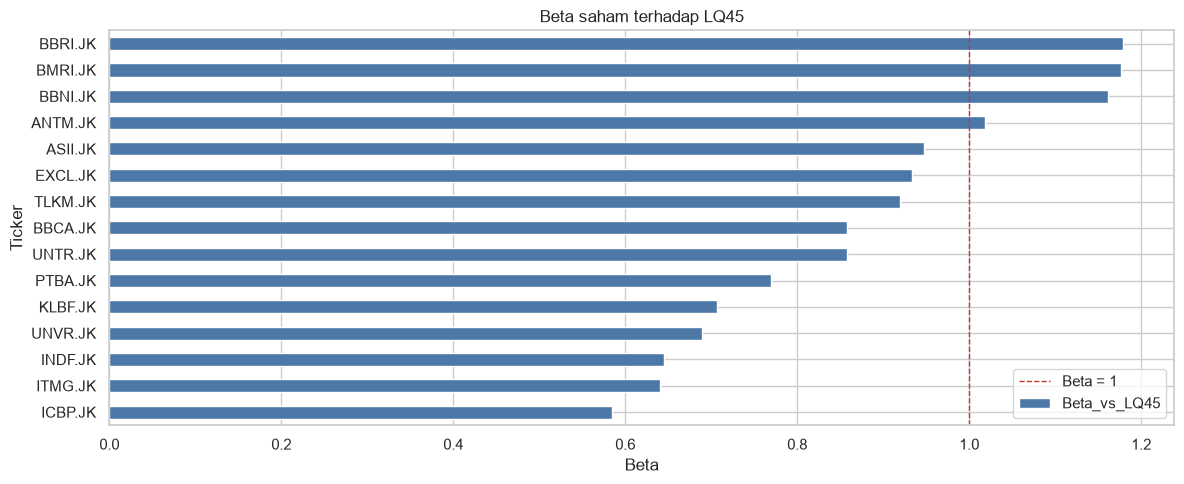

In [9]:
beta_rows = []
for ticker in stock_cols:
    aligned = pd.concat([stock_returns[ticker], lq45_return], axis=1).dropna()
    beta = aligned.iloc[:, 0].cov(aligned.iloc[:, 1]) / aligned.iloc[:, 1].var()
    beta_rows.append({'Ticker': ticker, 'Beta_vs_LQ45': beta, 'Observations': len(aligned)})
beta_lq45 = pd.DataFrame(beta_rows).set_index('Ticker').sort_values('Beta_vs_LQ45', ascending=False)
display(beta_lq45)

fig, ax = plt.subplots(figsize=(12, 5))
beta_lq45['Beta_vs_LQ45'].sort_values().plot.barh(ax=ax, color='#4c78a8')
ax.axvline(1, color='#c0392b', linestyle='--', linewidth=1, label='Beta = 1')
ax.set_title('Beta saham terhadap LQ45')
ax.set_xlabel('Beta')
ax.legend()
plt.tight_layout()
plt.show()

## 5 insight utama untuk README

In [10]:
top_kurtosis_ticker = distribution_stats['Kurtosis_Fisher'].idxmax()
top_kurtosis = distribution_stats.loc[top_kurtosis_ticker, 'Kurtosis_Fisher']
normality_rejections = int(distribution_stats['Reject_normality_5pct'].sum())
best_corr_pair = pd.DataFrame(pair_values).sort_values('Correlation', ascending=False).iloc[0]
mar_vol = crisis_summary.loc['Maret 2020', 'Mean_cross_sectional_vol']
apr_vol = crisis_summary.loc['April 2025', 'Mean_cross_sectional_vol']
highest_beta_ticker = beta_lq45.index[0]
lowest_beta_ticker = beta_lq45.index[-1]
price_stationary_count = int(adf_results.xs('price', level='Series')['Stationary_5pct'].sum())
return_stationary_count = int(adf_results.xs('log_return', level='Series')['Stationary_5pct'].sum())
macro_corr_abs = macro_corr.abs().sort_values(ascending=False)
strongest_macro = macro_corr_abs.index[0]
strongest_macro_value = macro_corr[strongest_macro]

readme_insights = [
    f'Distribusi log-return tidak normal pada {normality_rejections} dari {len(stock_cols)} saham menurut Jarque-Bera 5%; {top_kurtosis_ticker} memiliki excess kurtosis tertinggi ({top_kurtosis:.2f}), sehingga tail risk penting dalam pemodelan.',
    f'Uji ADF menandai {price_stationary_count}/{len(stock_cols)} seri harga dan {return_stationary_count}/{len(stock_cols)} seri log-return sebagai stasioner pada 5%; transformasi return tetap menjadi pilihan yang lebih aman untuk model time-series.',
    f'Korelasi return tertinggi terjadi antara {best_corr_pair.Ticker_1} dan {best_corr_pair.Ticker_2} ({best_corr_pair.Correlation:.2f}), menunjukkan konsentrasi faktor terutama pada saham perbankan.',
    f'Volatilitas rata-rata meningkat menjadi {mar_vol:.1%} pada Maret 2020 dan {apr_vol:.1%} pada April 2025, dibandingkan {cross_sectional_vol.mean():.1%} untuk seluruh periode; kedua jendela perlu diperlakukan sebagai regime stress.',
    f'Beta tertinggi terhadap LQ45 adalah {highest_beta_ticker} ({beta_lq45.iloc[0].Beta_vs_LQ45:.2f}) dan terendah {lowest_beta_ticker} ({beta_lq45.iloc[-1].Beta_vs_LQ45:.2f}); dari variabel makro yang diuji, korelasi absolut terbesar dengan return LQ45 berasal dari {strongest_macro} ({strongest_macro_value:.2f}).',
]
for number, insight in enumerate(readme_insights, start=1):
    display(Markdown(f'{number}. {insight}'))

1. Distribusi log-return tidak normal pada 15 dari 15 saham menurut Jarque-Bera 5%; PTBA.JK memiliki excess kurtosis tertinggi (8.34), sehingga tail risk penting dalam pemodelan.

2. Uji ADF menandai 1/15 seri harga dan 15/15 seri log-return sebagai stasioner pada 5%; transformasi return tetap menjadi pilihan yang lebih aman untuk model time-series.

3. Korelasi return tertinggi terjadi antara BMRI.JK dan BBNI.JK (0.68), menunjukkan konsentrasi faktor terutama pada saham perbankan.

4. Volatilitas rata-rata meningkat menjadi 55.1% pada Maret 2020 dan 50.3% pada April 2025, dibandingkan 32.1% untuk seluruh periode; kedua jendela perlu diperlakukan sebagai regime stress.

5. Beta tertinggi terhadap LQ45 adalah BBRI.JK (1.18) dan terendah ICBP.JK (0.58); dari variabel makro yang diuji, korelasi absolut terbesar dengan return LQ45 berasal dari USDIDR log-return (-0.11).